/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 3.254351603781941


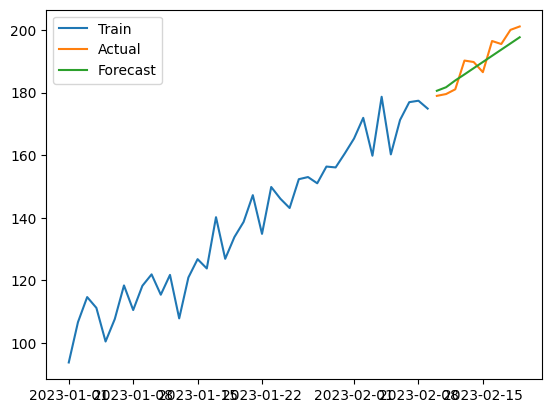

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Example time series data
data = {
    "date": pd.date_range(start="2023-01-01", periods=50, freq="D"),
    "sales": [100 + i * 2 + np.random.normal(0, 5) for i in range(50)]
}

df = pd.DataFrame(data)
df.set_index("date", inplace=True)
df.index=pd.to_datetime(df.index)
# Train-test split
train = df["sales"][:40]
test = df["sales"][40:]

# ARIMA(p, d, q)
# p = autoregressive lags
# d = differencing order
# q = moving average lags
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

# Forecast next values
forecast = model_fit.forecast(steps=len(test))

# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

# Plot
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


RMSE: 1.4826296124843898


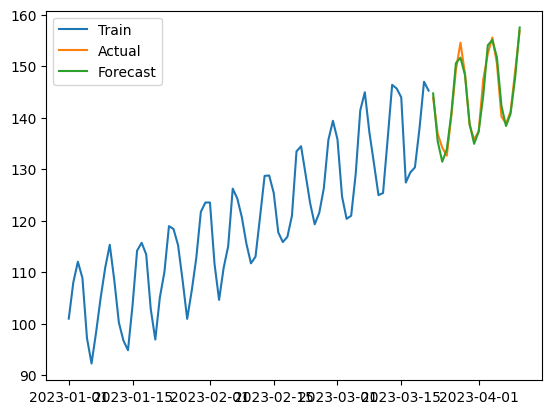

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Example seasonal time series data
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=100, freq="D")

trend = np.arange(100) * 0.5
seasonality = 10 * np.sin(2 * np.pi * np.arange(100) / 7)  # weekly seasonality
noise = np.random.normal(0, 2, 100)

sales = 100 + trend + seasonality + noise

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df.set_index("date", inplace=True)

# Train-test split
train = df["sales"][:80]
test = df["sales"][80:]

# SARIMA(p,d,q)(P,D,Q,s)
# (p,d,q) = non-seasonal ARIMA part
# (P,D,Q,s) = seasonal part
# s = seasonal period, here 7 for weekly seasonality
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

# Plot
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.show()

In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=100, freq="D")
trend = np.arange(100) * 0.5
seasonality = 10 * np.sin(2 * np.pi * np.arange(100) / 7)
noise = np.random.normal(0, 2, 100)

sales = 100 + trend + seasonality + noise
series = pd.Series(sales, index=dates)

initial_train_size = 70
predictions = []
actuals = []

for i in range(initial_train_size, len(series)):
    train = series[:i]
    actual = series.iloc[i]

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7)
    )

    model_fit = model.fit(disp=False)

    pred = model_fit.forecast(steps=1).iloc[0]

    predictions.append(pred)
    actuals.append(actual)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print("Walk-forward RMSE:", rmse)

Walk-forward RMSE: 2.2750008218397957
